In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("c:/Users/solan/Downloads/ai_jobs.csv")

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,UN0T2IZO2KCL,AI Researcher,MNC,Retail,Australia,Melbourne,Onsite,Senior,5,143800,174698,Full-time,2023,Medium
49996,CETZGCR42LC8,Data Scientist,Startup,Retail,Canada,Vancouver,Onsite,Senior,5,140248,161993,Full-time,2024,Medium
49997,EQ9PTEJEFKUI,Data Analyst,Startup,Healthcare,USA,New York,Onsite,Entry,0,50953,87158,Full-time,2022,Small
49998,92UNH47RTAGS,Data Scientist,Research Lab,Healthcare,USA,Austin,Hybrid,Entry,0,63712,76213,Full-time,2020,Large


In [4]:
df.head()

,job_id,job_title,company_type,industry,country,city,remote_type,experience_level,min_experience_years,salary_min_usd,salary_max_usd,employment_type,posted_year,company_size
0,0IFD0TVBDIVU,MLOps Engineer,Research Lab,Education,Australia,Remote,Remote,Entry,0,56873,72223,Full-time,2023,Large
1,ZMF8MDD4V30T,Data Analyst,Startup,Education,Germany,Remote,Remote,Entry,0,54803,85599,Full-time,2024,Medium
2,CX1945NQ4FMY,MLOps Engineer,Research Lab,Tech,Canada,Remote,Remote,Senior,5,149980,175806,Full-time,2021,Large
3,QJ7YHL1C32OC,Applied Scientist,Research Lab,Healthcare,Australia,Remote,Remote,Entry,0,53483,86477,Full-time,2023,Medium
4,F0T0PVN9ER14,Machine Learning Engineer,Research Lab,Finance,Australia,Sydney,Hybrid,Mid,2,102977,127298,Full-time,2023,Large


In [5]:
df.shape

(50000, 14)

In [6]:
df.columns

Index(['job_id', 'job_title', 'company_type', 'industry', 'country', 'city',
       'remote_type', 'experience_level', 'min_experience_years',
       'salary_min_usd', 'salary_max_usd', 'employment_type', 'posted_year',
       'company_size'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   job_id                50000 non-null  object
 1   job_title             50000 non-null  object
 2   company_type          50000 non-null  object
 3   industry              50000 non-null  object
 4   country               50000 non-null  object
 5   city                  50000 non-null  object
 6   remote_type           50000 non-null  object
 7   experience_level      50000 non-null  object
 8   min_experience_years  50000 non-null  int64 
 9   salary_min_usd        50000 non-null  int64 
 10  salary_max_usd        50000 non-null  int64 
 11  employment_type       50000 non-null  object
 12  posted_year           50000 non-null  int64 
 13  company_size          50000 non-null  object
dtypes: int64(4), object(10)
memory usage: 5.3+ MB


In [9]:
df.isnull().sum()

job_id                  0
job_title               0
company_type            0
industry                0
country                 0
city                    0
remote_type             0
experience_level        0
min_experience_years    0
salary_min_usd          0
salary_max_usd          0
employment_type         0
posted_year             0
company_size            0
dtype: int64

C:\Users\solan\AppData\Local\Temp\ipykernel_23772\1247548194.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  a = sns.countplot(x='job_title',data=df,palette='husl')


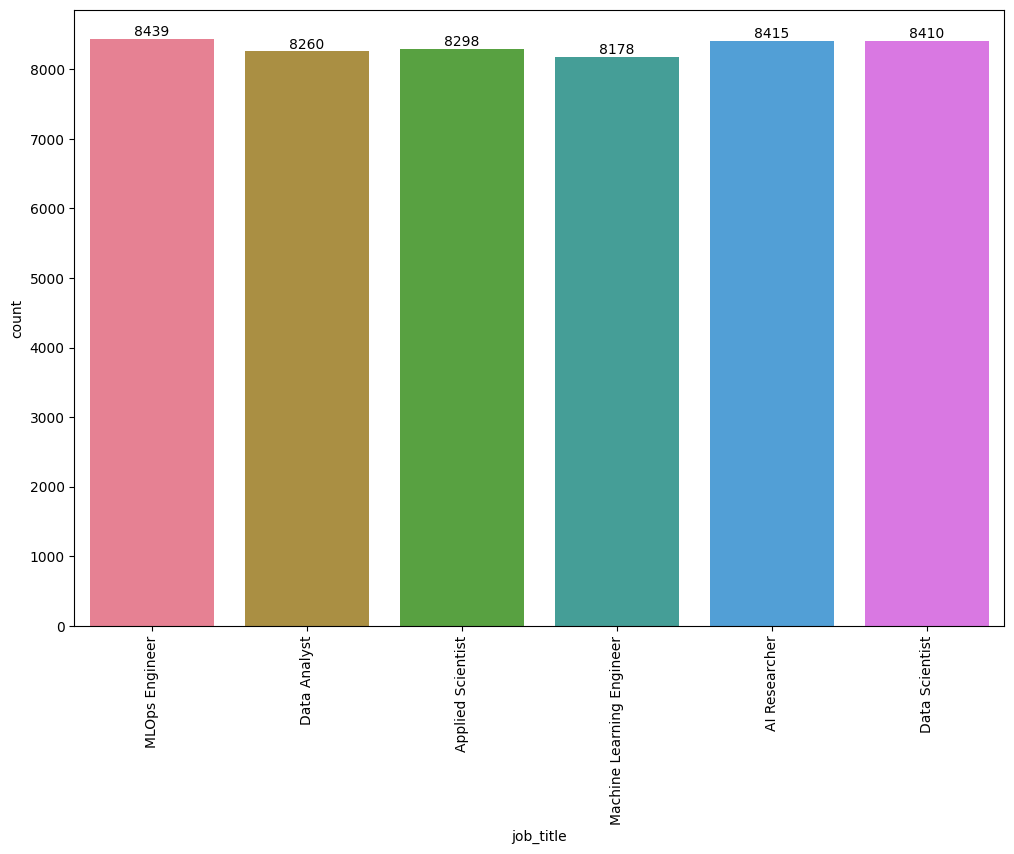

In [46]:
plt.figure(figsize=(12,8))
a = sns.countplot(x='job_title',data=df,palette='husl')
for i in a.containers:
    a.bar_label(i)
plt.xticks(rotation=90)
plt.show()

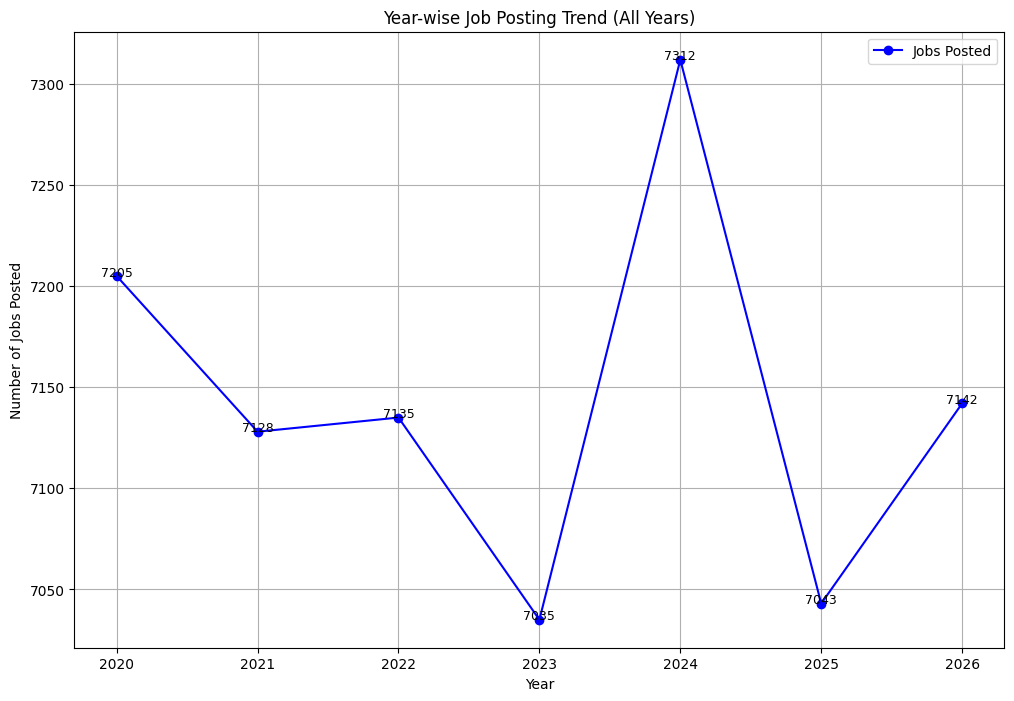

In [182]:
plt.figure(figsize=(12,8))
year_trend = (df['posted_year'].value_counts().sort_index())
year_trend.plot(kind='line', marker='o', color='b',label='Jobs Posted')
plt.legend()
for i in year_trend.index:
    plt.text(i, year_trend[i], year_trend[i], ha='center', fontsize=9)
plt.title("Year-wise Job Posting Trend (All Years)")
plt.xlabel("Year")
plt.ylabel("Number of Jobs Posted")
plt.grid(True)
plt.show()


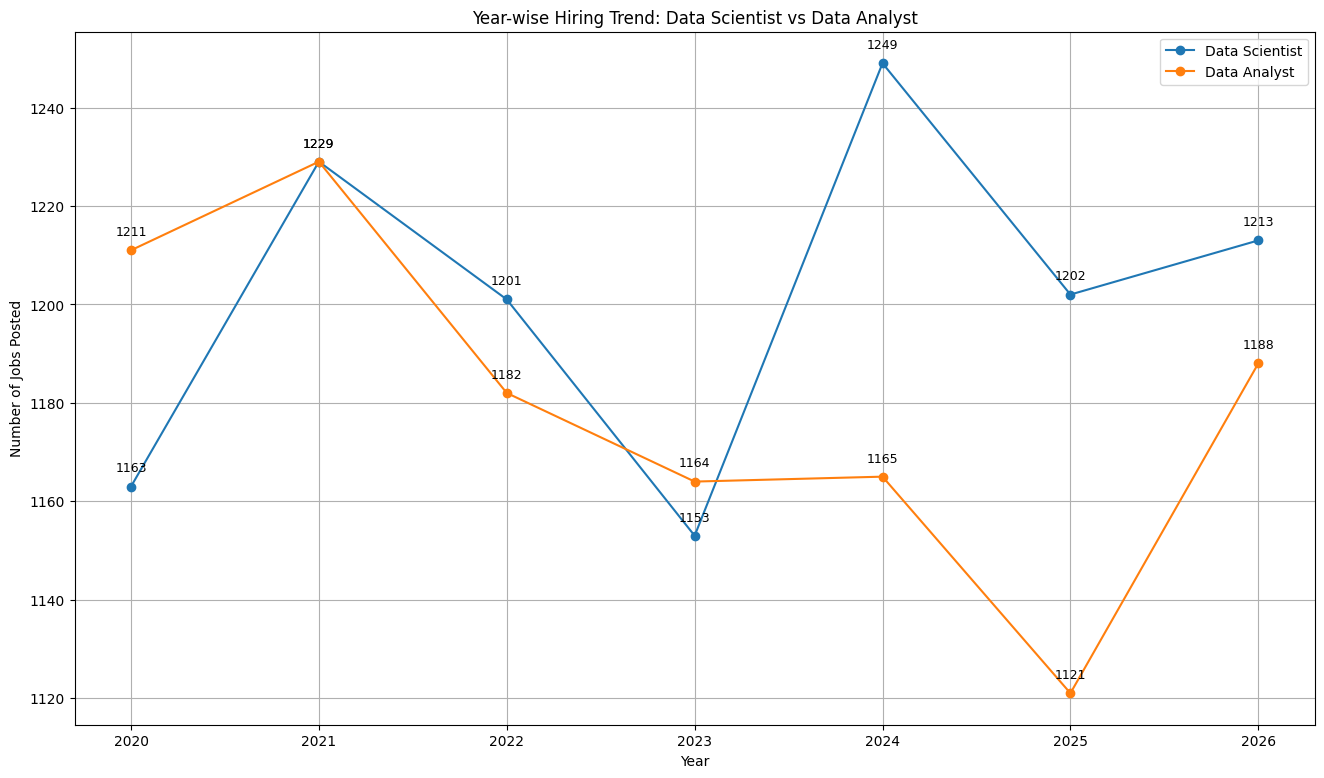

In [62]:
# Filter data
ds = df[df['job_title'] == 'Data Scientist']
da = df[df['job_title'] == 'Data Analyst']


# Year-wise count
ds_year = ds.groupby('posted_year').size()
da_year = da.groupby('posted_year').size()

# Plot
plt.figure(figsize=(16, 9))

plt.plot(ds_year.index, ds_year.values,
         marker='o', label='Data Scientist')

plt.plot(da_year.index, da_year.values,
         marker='o', label='Data Analyst')

# Values on points (optional but recommended)
for x, y in zip(ds_year.index, ds_year.values):
    plt.text(x, y+3, y, ha='center', fontsize=9)

for x, y in zip(da_year.index, da_year.values):
    plt.text(x, y+3, y, ha='center', fontsize=9)

plt.title("Year-wise Hiring Trend: Data Scientist vs Data Analyst")
plt.xlabel("Year")
plt.ylabel("Number of Jobs Posted")
plt.legend()
plt.grid(True)
plt.show()


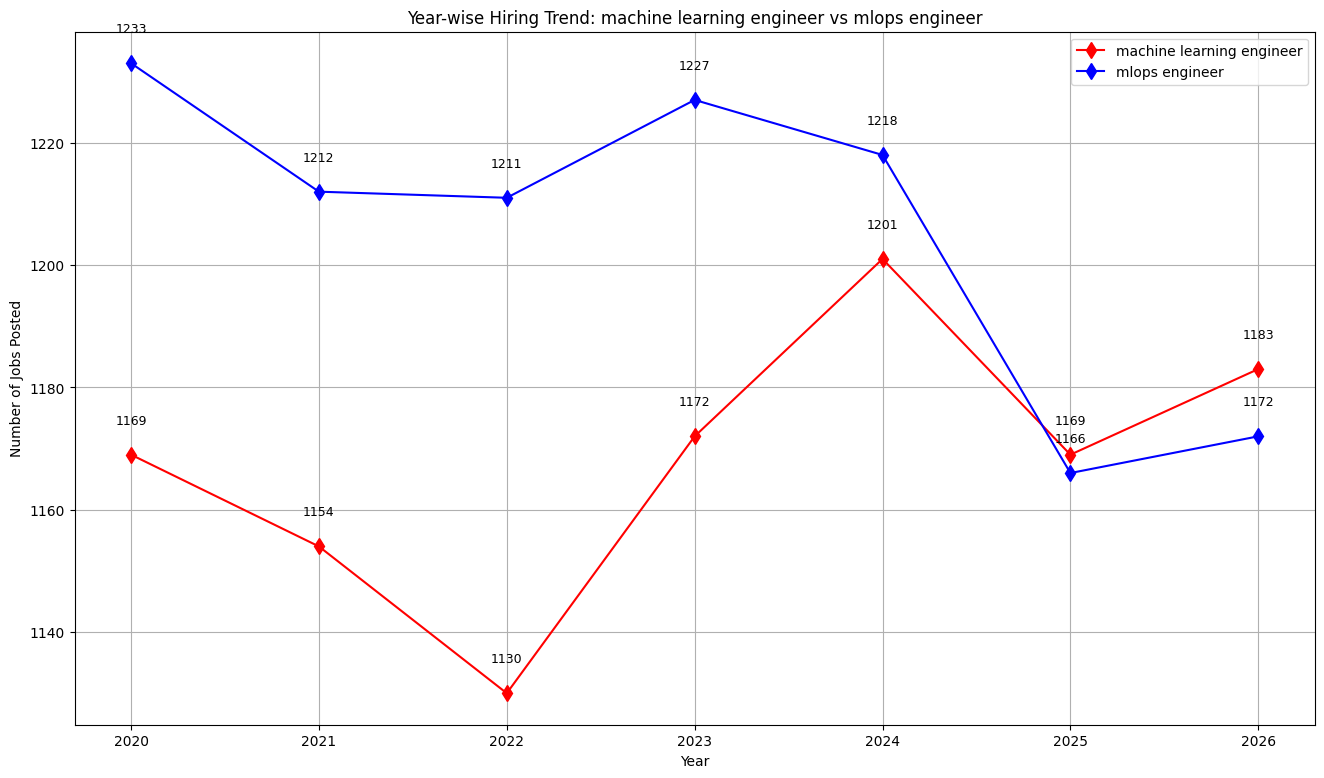

In [75]:
mle = df[df['job_title']=='Machine Learning Engineer']
mlo =df[df['job_title']=='MLOps Engineer']

mle_year=mle.groupby('posted_year').size()
mlo_year=mlo.groupby('posted_year').size()

plt.figure(figsize=(16, 9))

plt.plot(mle_year.index,mle_year.values,marker='d',markersize=8,color='red',label='machine learning engineer')
for x,y in zip(mle_year.index,mle_year.values):
    plt.text(x,y+5,y,ha='center',fontsize=9)
    
    
plt.plot(mlo_year.index,mlo_year.values,marker='d',markersize=8,color='blue',label='mlops engineer')
for a,b in zip(mlo_year.index,mlo_year.values):
    plt.text(a,b+5,b,ha='center',fontsize=9)
    
plt.title("Year-wise Hiring Trend: machine learning engineer vs mlops engineer")
plt.xlabel("Year")
plt.ylabel("Number of Jobs Posted")
plt.legend()
plt.grid(True)
plt.show()
    





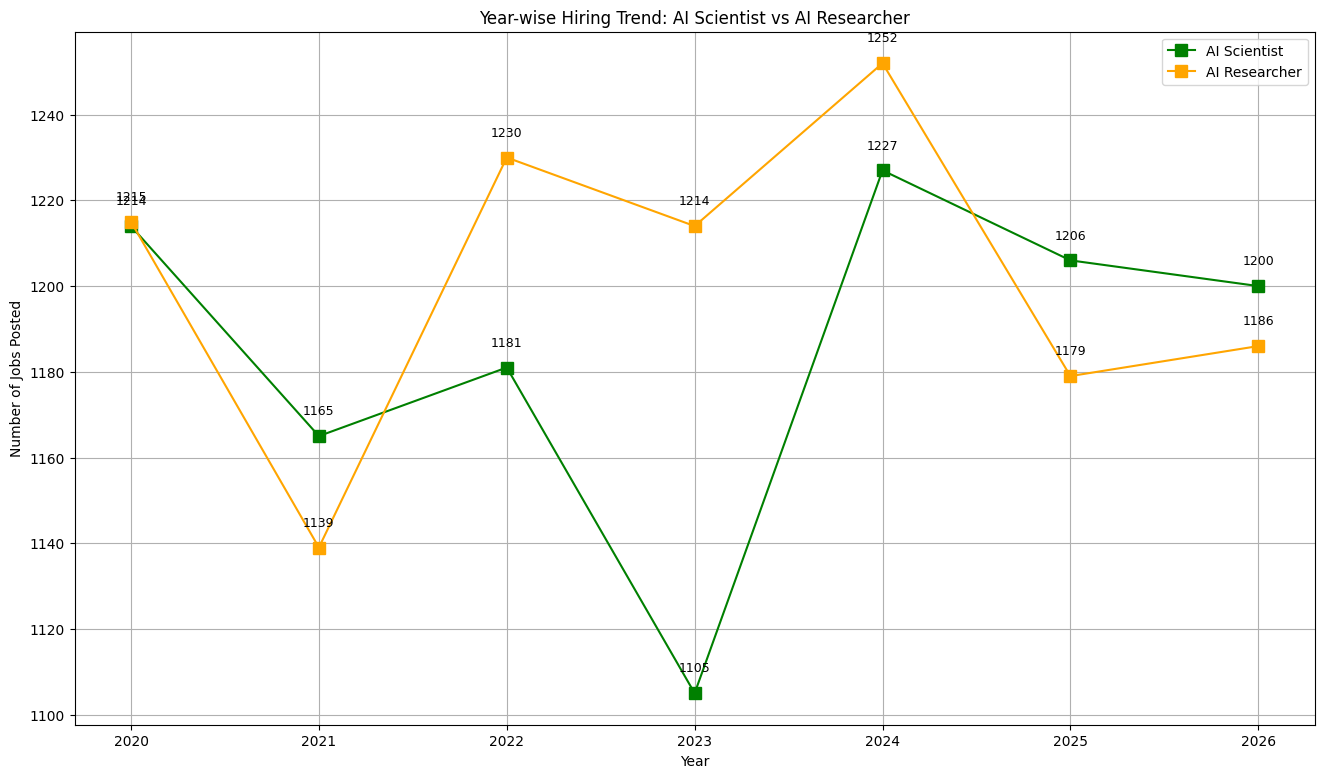

In [82]:
Aps = df[df['job_title']=='Applied Scientist']
ar = df[df['job_title']=='AI Researcher']   

Aps_year=Aps.groupby('posted_year').size()
ar_year=ar.groupby('posted_year').size()

plt.figure(figsize=(16, 9))
plt.plot(Aps_year.index,Aps_year.values,marker='s',markersize=8,color='green',label='AI Scientist')
for x,y in zip(Aps_year.index,Aps_year.values):
    plt.text(x,y+5,y,ha='center',fontsize=9)
    
plt.plot(ar_year.index,ar_year.values,marker='s',markersize=8,color='orange',label='AI Researcher')
for a,b in zip(ar_year.index,ar_year.values):
    plt.text(a,b+5,b,ha='center',fontsize=9)
    
plt.title("Year-wise Hiring Trend: AI Scientist vs AI Researcher")
plt.xlabel("Year")
plt.ylabel("Number of Jobs Posted")
plt.legend()
plt.grid(True)
plt.show()

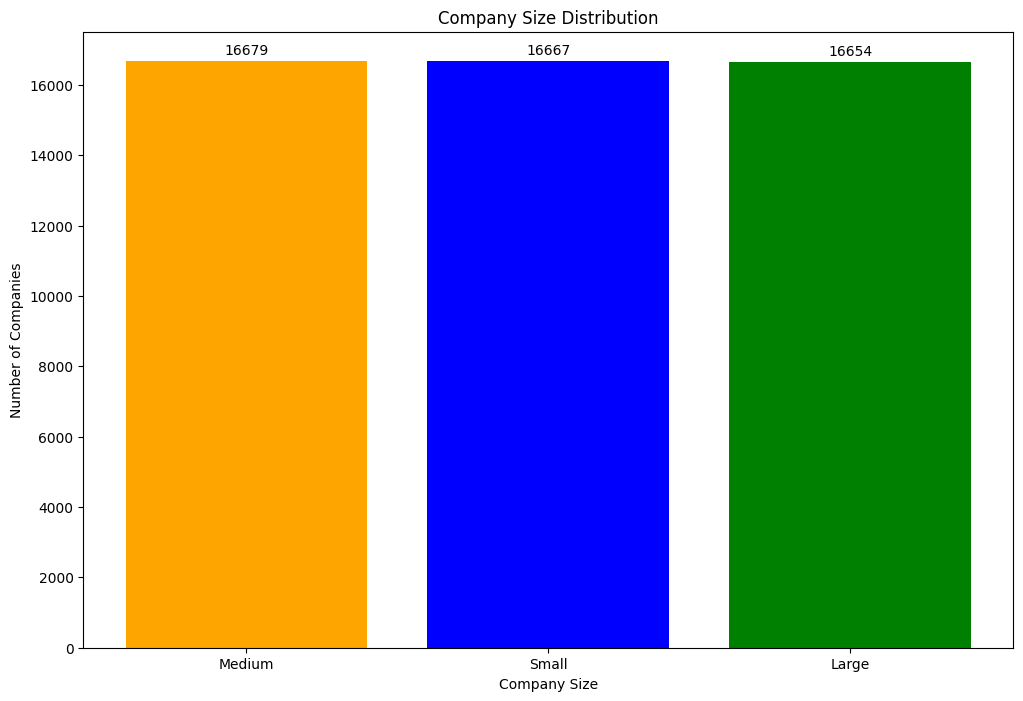

In [106]:
plt.figure(figsize=(12, 8))
counts = df['company_size'].value_counts()
plt.style.use('default')

colors = ['orange', 'blue', 'green']

plt.bar(counts.index,counts.values,color=colors)

for i, v in enumerate(counts.values):
    plt.text(i, v + 200, v, ha='center', fontsize=10)

plt.title("Company Size Distribution")
plt.xlabel("Company Size")
plt.ylabel("Number of Companies")
plt.show()


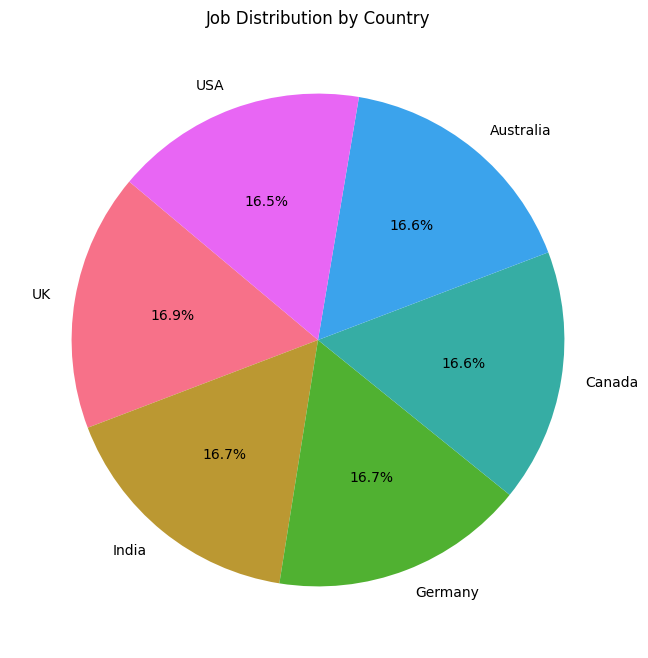

In [184]:
plt.figure(figsize=(12, 8))
plt.pie(df['country'].value_counts(), labels=df['country'].value_counts().index,autopct='%1.1f%%', startangle=140, colors=sns.color_palette('husl'))
plt.title("Job Distribution by Country")
plt.show()


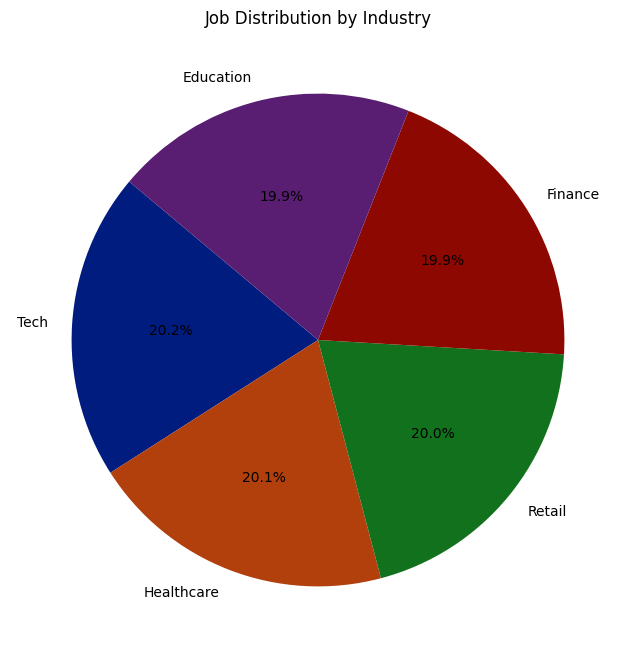

In [174]:
plt.figure(figsize=(12, 8))
plt.pie(df['industry'].value_counts(),labels=df['industry'].value_counts().index,autopct='%1.1f%%',startangle=140, colors=sns.color_palette('dark'))
plt.title("Job Distribution by Industry")
plt.show()

C:\Users\solan\AppData\Local\Temp\ipykernel_23772\91986996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='city',data=df,palette='tab20')


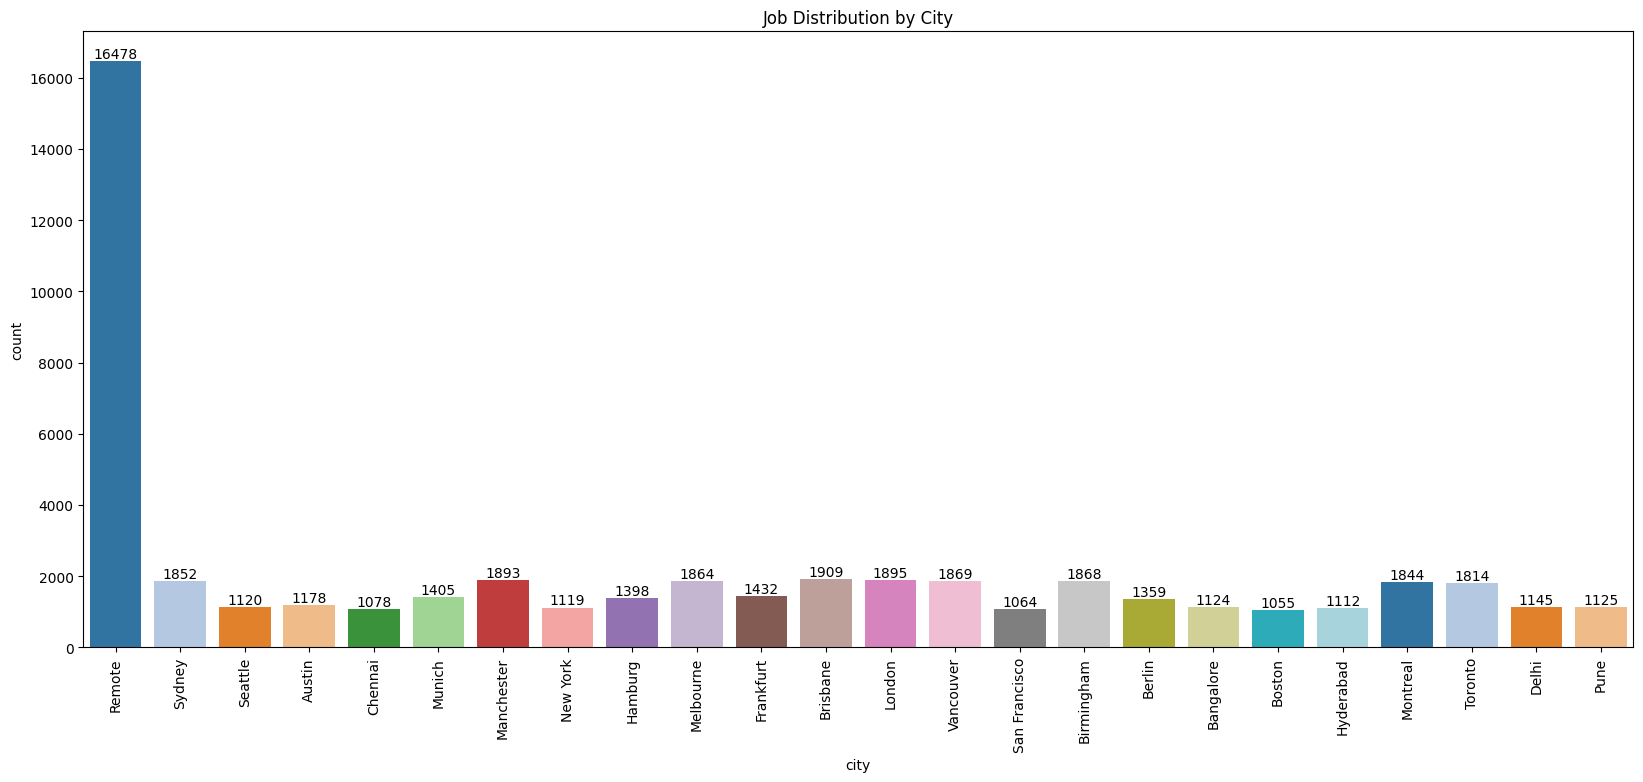

In [156]:
plt.figure(figsize=(20, 8))
sns.countplot(x='city',data=df,palette='tab20')
for i in plt.gca().containers:
    plt.gca().bar_label(i)
plt.xticks(rotation=90)
plt.title("Job Distribution by City")
plt.show()
year_count = df['posted_year'].value_counts().sort_index()



C:\Users\solan\AppData\Local\Temp\ipykernel_23772\886478839.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mnc_city.index,y=mnc_city.values,palette='viridis')


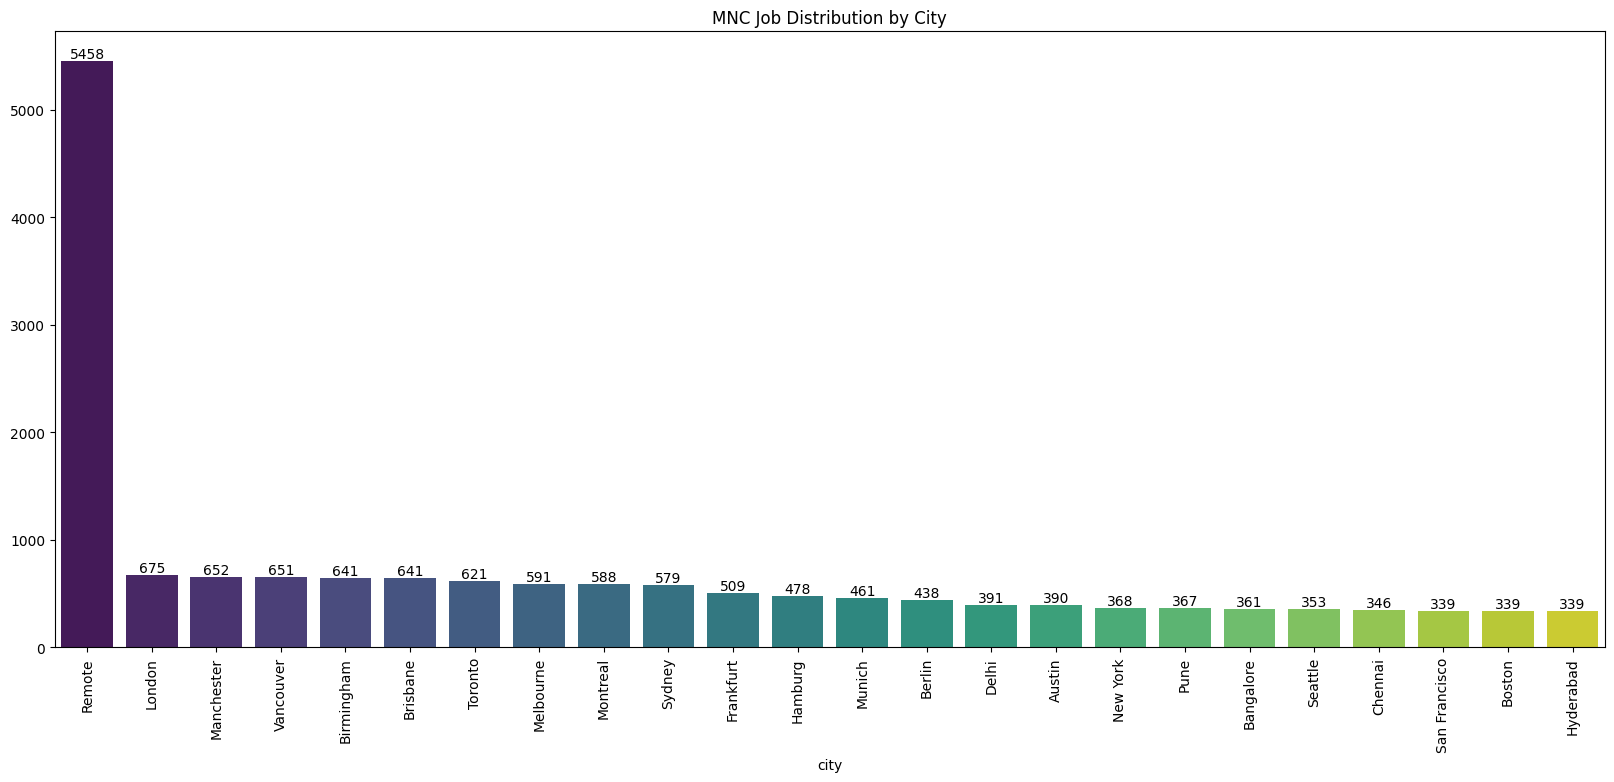

In [175]:
mnc_c = df[df['company_type']=='MNC']
mnc_city = mnc_c['city'].value_counts()

plt.figure(figsize=(20, 8))
sns.barplot(x=mnc_city.index,y=mnc_city.values,palette='viridis')
for i in plt.gca().containers: 
    plt.gca().bar_label(i)
plt.xticks(rotation=90)
plt.title("MNC Job Distribution by City")
plt.show()

array([0, 5, 2])

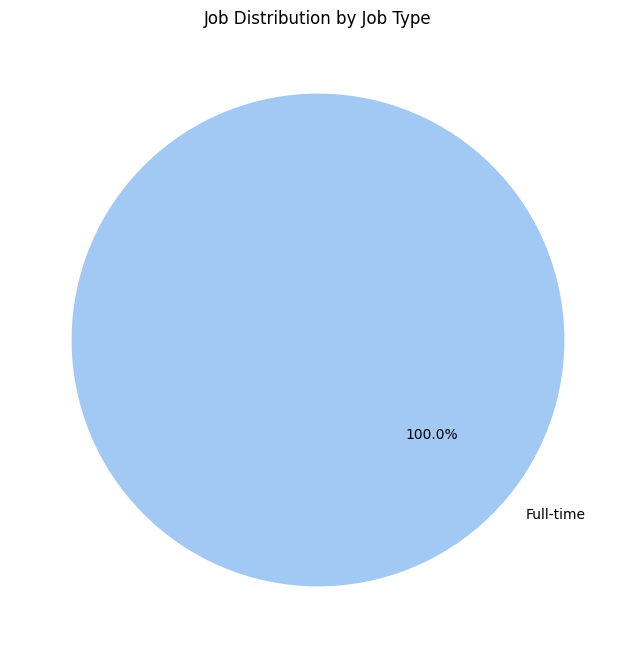

In [167]:
plt.figure(figsize=(12, 8))
plt.pie(df[ 'employment_type'].value_counts(), labels=df[ 'employment_type'].value_counts().index,autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Job Distribution by Job Type")
plt.show()

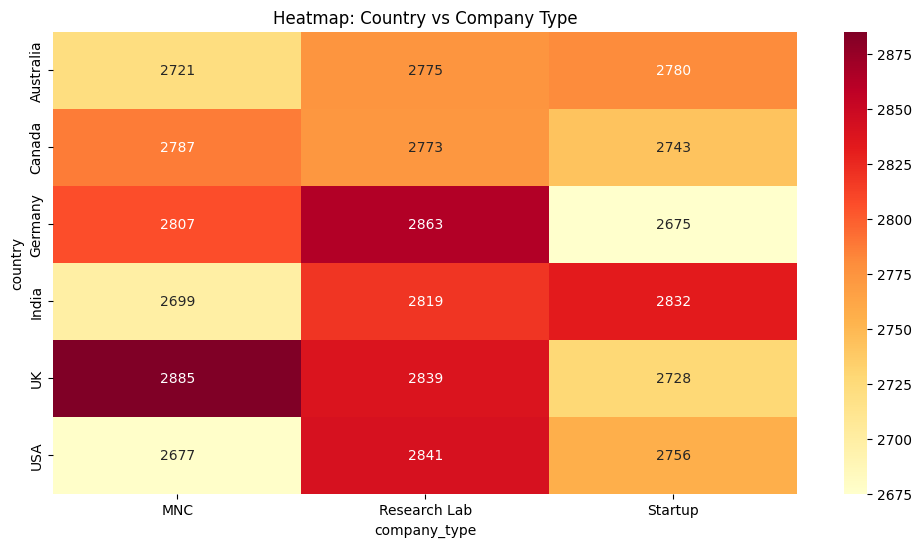

In [169]:
pivot_ct = pd.pivot_table(
    df,
    values='job_id',
    index='country',
    columns='company_type',
    aggfunc='count'
)

plt.figure(figsize=(12, 6))
sns.heatmap(
    pivot_ct,
    annot=True,
    fmt='g',
    cmap='YlOrRd'
)
plt.title("Heatmap: Country vs Company Type")
plt.show()


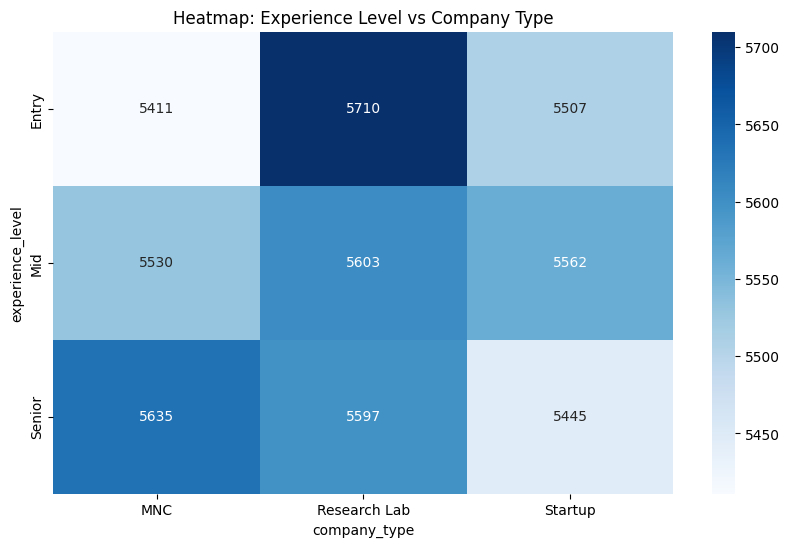

In [170]:
pivot_exp = pd.pivot_table(
    df,
    values='job_id',
    index='experience_level',
    columns='company_type',
    aggfunc='count'
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_exp,
    annot=True,
    fmt='g',
    cmap='Blues'
)
plt.title("Heatmap: Experience Level vs Company Type")
plt.show()


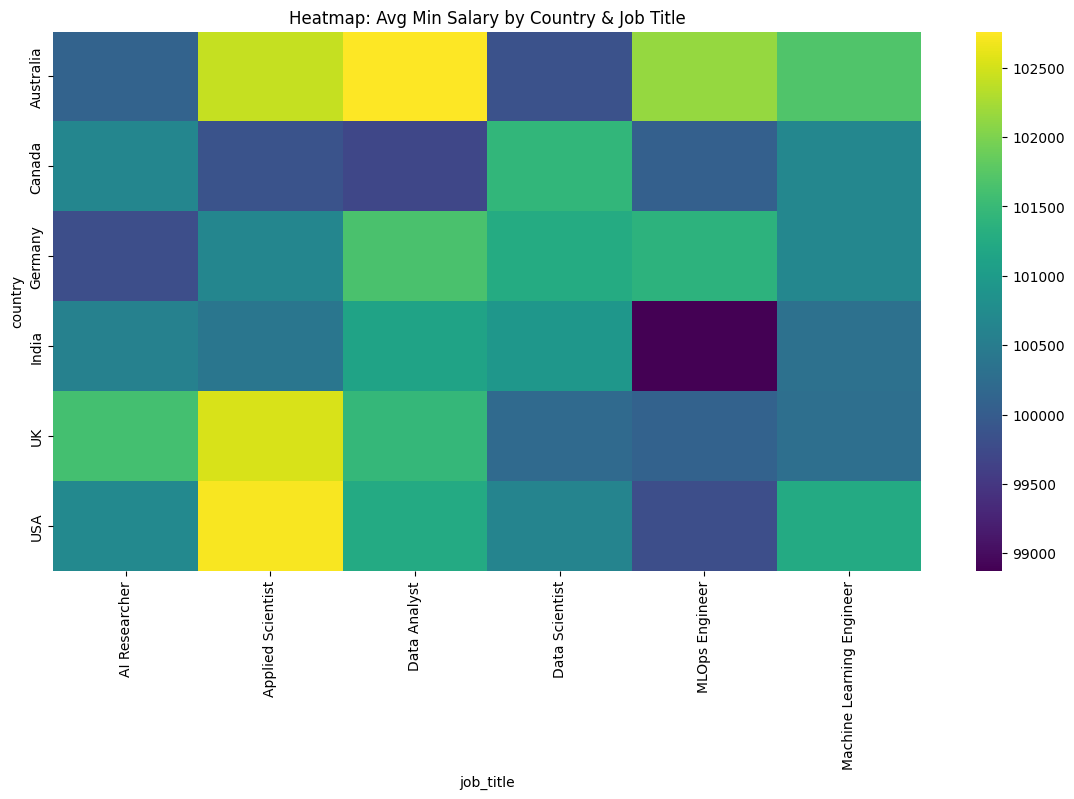

In [178]:
pivot_salary = pd.pivot_table(
    df,
    values='salary_min_usd',
    index='country',
    columns='job_title',
    aggfunc='mean'
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_salary,


    cmap='viridis'
)
plt.title("Heatmap: Avg Min Salary by Country & Job Title")
plt.show()
